<a href="https://colab.research.google.com/github/HusseinWaleed1/Semantic_Search/blob/main/vector_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

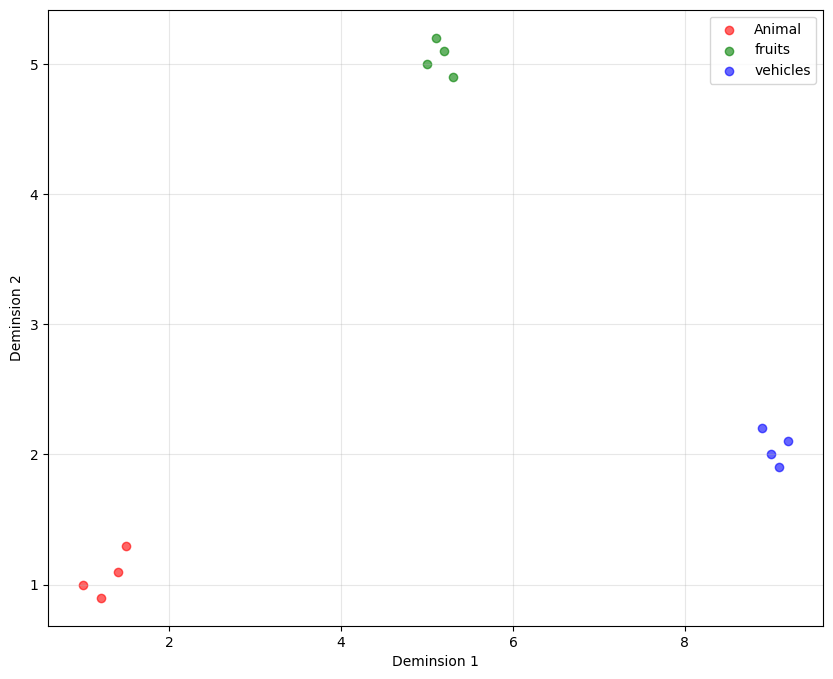

In [ ]:
# simulate words to 2d embeddings
word_animals =["cat","dog","lion","tiger"]
word_fruits =["apple","banana","orange","grape"]
word_vehicles =["truck","car","bus","train"]

embedding_animals =np.array([[1,1],[1.2,.9],[1.5,1.3],[1.4,1.1]])
embedding_fruits =np.array([[5,5],[5.1,5.2],[5.3,4.9],[5.2,5.1]])
embedding_vehicles =np.array([[9,2],[9.2,2.1],[8.9,2.2],[9.1,1.9]])


#visualization

plt.figure(figsize=(10,8)) #CM
plt.scatter(embedding_animals[:,0],embedding_animals[:,1],color="red",alpha=.6,label="Animal")
plt.scatter(embedding_fruits[:,0],embedding_fruits[:,1],color="green",alpha=.6,label="fruits")
plt.scatter(embedding_vehicles[:,0],embedding_vehicles[:,1],color="blue",alpha=.6,label="vehicles")

plt.xlabel("Deminsion 1")
plt.ylabel("Deminsion 2")

plt.legend()

plt.grid(True,alpha=.3)
plt.show()


In [ ]:
embedding_animals[:,0]

array([1. , 1.2, 1.5, 1.4])

In [ ]:
# the cat sits on the mat with another cat

# the 2
# cat 2
# sits 1

# the [01,21,26,14]
# the cat [05,35,154]

# place [...] 384 the
# place [...] 384 the cat
# place [...] 384 the cat sits on the mat


In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2") # download weight one time! load direct next time # 384
# example sentences
sentences = ["the cat sits on the mat",
             "A dog rests on a rug",
             "Dogs are loyal animals",
             "Python is a programming language",
             "Machine learning is amazing",
             "Java Script is popular"]


# generate embeddings
embeddings = model.encode(sentences)
print(len(sentences))
print(embeddings.shape[1])
print(embeddings.shape)

print(embeddings[0][:10])

C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6
384
(6, 384)
[ 0.13489059 -0.03206334 -0.02033523  0.03590105 -0.02833315  0.04150213
  0.03315869  0.03660567  0.00861664  0.03763953]


In [ ]:
embeddings[0]

array([ 1.34890586e-01, -3.20633426e-02, -2.03352328e-02,  3.59010510e-02,
       -2.83331461e-02,  4.15021256e-02,  3.31586897e-02,  3.66056710e-02,
        8.61663558e-03,  3.76395322e-02, -2.95941308e-02,  6.16296269e-02,
        3.35186683e-02,  2.61421110e-02, -2.21841298e-02, -4.26911712e-02,
       -7.45386854e-02, -2.25513615e-02,  9.23976675e-02,  3.82272974e-02,
       -3.43200639e-02, -1.08189946e-02,  2.45938785e-02, -7.65806511e-02,
       -5.34536578e-02,  7.45100901e-02, -4.00889516e-02, -1.99211370e-02,
        3.29958498e-02, -1.60427857e-02, -5.31752855e-02, -8.46040901e-03,
        1.44567154e-02,  4.07941490e-02,  1.89681649e-02, -8.80274773e-02,
       -1.73724955e-03, -6.00840226e-02,  3.24572213e-02,  2.28254180e-02,
        5.60978986e-02,  2.80693676e-02,  6.25540211e-04, -7.13450015e-02,
        1.62076149e-02, -8.53964314e-03,  1.02216817e-01, -1.20048337e-01,
        5.76661751e-02,  7.36913458e-03, -9.64395553e-02,  7.09043071e-02,
        3.70082259e-02,  

In [ ]:
# measuring similarity
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# compute cosine similarity
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 1.0000004   0.49771792  0.14571491  0.03173616 -0.06890164 -0.03495288]
 [ 0.49771792  1.0000001   0.32005975  0.06851154 -0.04416235  0.04045829]
 [ 0.14571491  0.32005975  0.99999994  0.11677916  0.04157627  0.13984498]
 [ 0.03173616  0.06851154  0.11677916  1.0000001   0.203517    0.3136458 ]
 [-0.06890164 -0.04416235  0.04157627  0.203517    0.9999999   0.3710927 ]
 [-0.03495288  0.04045829  0.13984498  0.3136458   0.3710927   1.        ]]


In [ ]:
sentences

['the cat sits on the mat',
 'A dog rests on a rug',
 'Dogs are loyal animals',
 'Python is a programming language',
 'Machine learning is amazing',
 'Java Script is popular']

In [ ]:
df_sim = pd.DataFrame(similarity_matrix,index=[f"S{i+1}" for i in range(len(sentences))],columns=[f"S{i+1}" for i in range(len(sentences))])
df_sim

,S1,S2,S3,S4,S5,S6
S1,1.000000,0.497718,0.145715,0.031736,-0.068902,-0.034953
S2,0.497718,1.000000,0.320060,0.068512,-0.044162,0.040458
S3,0.145715,0.320060,1.000000,0.116779,0.041576,0.139845
S4,0.031736,0.068512,0.116779,1.000000,0.203517,0.313646
S5,-0.068902,-0.044162,0.041576,0.203517,1.000000,0.371093
S6,-0.034953,0.040458,0.139845,0.313646,0.371093,1.000000


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

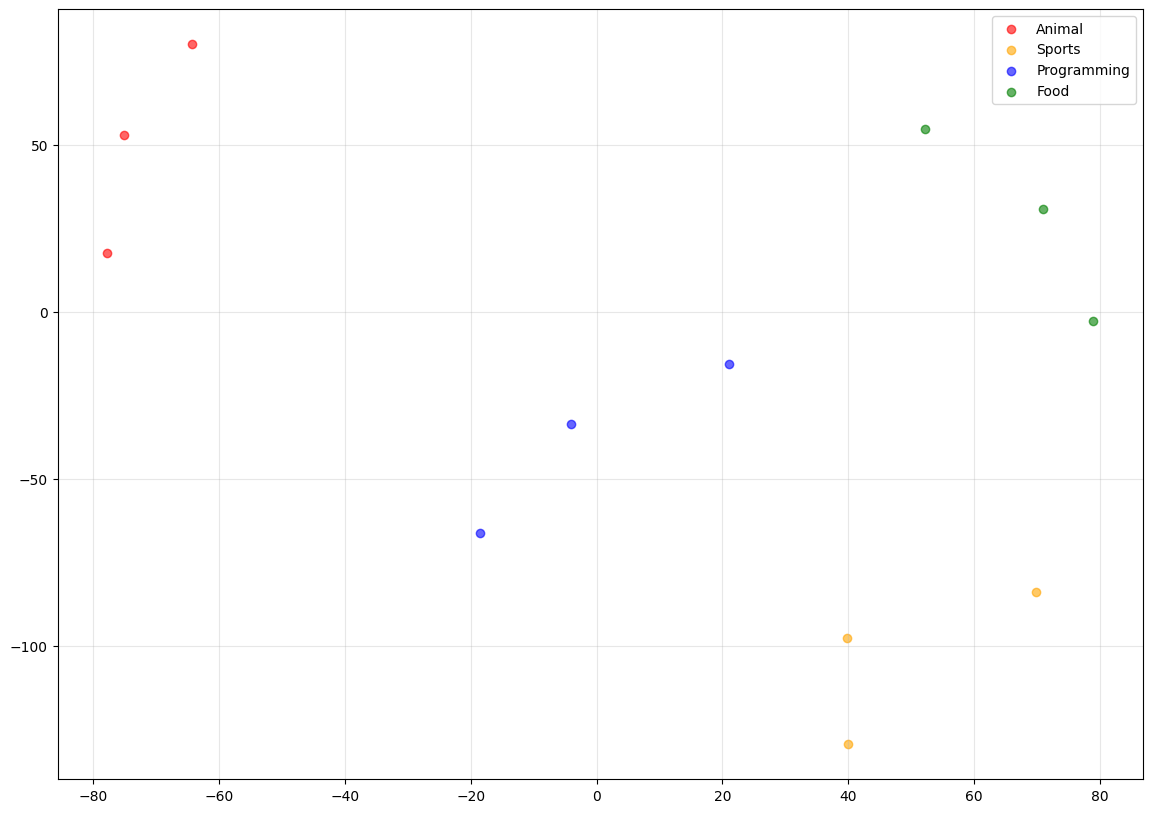

In [ ]:
Sentences = [
#animal
'the cat sits on the mat',
 'A dog rests on a rug',
 'Dogs are loyal animals',
 # programming languages
 'Python is a programming language',
 'Machine learning is amazing',
 'Java Script is popular'
 #food,
 ,"Pizza is delicious",
 "I love eating sushi"
 ,"Chocolate cake is sweet"

# sports
 ,"Basketball is a team sport",
 "soccer is popular around the world",
 "Tennis requires skills"]
categories = ["Animal"] *3 +["Programming"]*3+["Food"]*3 +["Sports"]*3
colors_map = {"Animal":"red","Programming":"blue","Food":"green","Sports":"orange"}
embedding_divers = model.encode(Sentences)

# reduce embedding into 2d using T-sne
tsne = TSNE(n_components=2,perplexity=5)
embedding_2d = tsne.fit_transform(embedding_divers)


plt.figure(figsize=(14,10))
for category in set(categories):
    mask=[c==category for c in categories] # same category
    plt.scatter(embedding_2d[mask,0],embedding_2d[mask,1],
    c=colors_map[category],label=category,alpha=.6)
plt.legend()
plt.grid(True,alpha=.3)
plt.show()

In [ ]:
categories

['Animal',
 'Animal',
 'Animal',
 'Programming',
 'Programming',
 'Programming',
 'Food',
 'Food',
 'Food',
 'sports',
 'sports',
 'sports']

In [ ]:
embedding_divers.shape

(12, 384)

# Semantic Search

In [ ]:
# create simple semantic search
class SimpleSemanticSearch:
    def __init__(self,model_name="all-MiniLM-L6-v2"):
        self.model=SentenceTransformer(model_name) # load
        self.documents=[]
        self.embeddings=None
    def add_documents(self,documents):
        print("encoding now")
        self.documents=documents
        self.embeddings=self.model.encode(documents)
        print("encoding done")
    def search(self,query,top_k=3): # top_k ranking documents
        query_embedding=self.model.encode([query])[0] # text direct to V db X  # question text > embedding > V Db
        print(query_embedding.shape)
        similarities = cosine_similarity([query_embedding],self.embeddings)[0]

        # get top-k results
        top_indcies = np.argsort(similarities)[::-1][:top_k]
        results =[]
        for idx in top_indcies:
            results.append({"document":self.documents[idx],
                            "score":similarities[idx],
                            "rank":len(results)+1})
        return results

In [ ]:
search_engine = SimpleSemanticSearch() # create and load model
documents = ["Machine learning is a subset of artificial intelligence",
             "Python is a popular programming language for data science",
             "Neural Networks are inspired by human brain",
             "Deep learning uses multiple layers of neural networks",
             "Data preprocessing is crucial for model performance",
             "Overfitting occurs when a model memorize training data",
             "Cross validation helps evaluate model generalization"]
search_engine.add_documents(documents)

encoding now
encoding done


In [ ]:
queries= ["What is Ai?","how neural networks work?","best language for data science?"]

for query in queries:
    print("Question",query)
    results = search_engine.search(query,top_k=1)
    for result in results:
        print(result["rank"],result["score"])
        print("Document words",result["document"])

Question What is Ai?
(384,)
1 0.56897485
Document words Machine learning is a subset of artificial intelligence
Question how neural networks work?
(384,)
1 0.66638064
Document words Neural Networks are inspired by human brain
Question best language for data science?
(384,)
1 0.6694472
Document words Python is a popular programming language for data science
